## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [9]:
# Your Phase 1 solution to the problem goes here.
# I completed this version without generative AI.

1. What is the difference between regression and classification?  
Regression predicts a numerical value. Classification predicts a category.

2. What is a confusion table? What does it help us understand about a model's performance?  
A confusion table is a table which compares the true labels with the predicted labels and counts the number of correct and incorrect predictions for each class, indicating which classes the model confuses and what types of errors it makes.

3. What does the SSE quantify about a particular model?  
SSE is a measure of the total of the squared differences between the actual and the predicted numerical values, if the SSE is lower then the predictions are more accurate for the same dataset, and the process of squaring causes larger errors to count more.

4. What are overfitting and underfitting?  
Overfitting is when a model learns the noise present in the training data rather than the actual patterns, which causes it to perform well on the training data but badly on new data. Underfitting is when the model is too simple to capture the important patterns and therefore performs poorly on both the training and new data.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?  
The training and testing split involves using data that has not been seen before to determine whether a model is generalizing rather than going off the training examples. The model should be selected on the basis of higher accuracy or lower SSE when evaluated on the held out data because that leads to better performance on future observations. You should also validate to make sure you are not overfitting.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.  
Class labels are easy to understand and immediately useful, but they do not show uncertainty since a prediction that is only slightly in favour appears no different from one that is very confident. Probability distributions do reveal the uncertainty and allow you to set decision thresholds according to the costs of different types of errors. Yet they are more complicated, require a decision rule if only a single label is needed, and can be misleading if the probabilities are not well calibrated.

Data Head:
     voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1

Summary Statistics:
           voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000

Class Distribution:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Optimal k selected: 2

Confusion Matrix:
 [[17  0 18  2  0]
 [ 0 25  4  4  0]
 [ 8  3 16  2  3]
 [12  5 10  7  2]
 [ 8  2 12  6  3]]


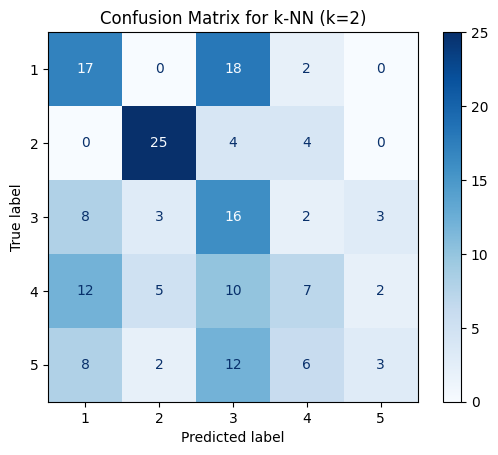


Test Set Accuracy: 40.24%


In [10]:
# Q2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# load the dataset
df = pd.read_csv("land_mines.csv")

# eda of the features and the target label (mine_type)
# 338 mines, features are all scaled 0 to 1 (voltage ranges only 0.2 to 1, mean 0.43)
# the 5 mine types are nearly balanced (65 to 71 each), so always guessing one type gets ~21%
print("Data Head:\n", df.head())
print("\nSummary Statistics:\n", df.describe())
print("\nClass Distribution:\n", df["mine_type"].value_counts())

# split the sample 50/50 into training and test sets
# an even split is used since the data is small, so the test set still has enough of each type
# (31 to 37 per type in the test set)
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# build the k-NN classifier and select k using test accuracy
# small k overfits (high train accuracy, lower test accuracy), large k oversmooths
# so the k with the highest test accuracy is the best balance of the two
train_acc = []
test_acc = []
k_values = range(1, 20)

# fit a model for each k and record train and test accuracy
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  train_acc.append(knn.score(X_train, y_train))
  test_acc.append(knn.score(X_test, y_test))

# pick the k with the highest test accuracy
# k = 2 is selected with a test accuracy of about 40.2%
# test accuracy is low and noisy across k (about 30% to 40%), so the choice of k is not very strong
optimal_k = k_values[np.argmax(test_acc)]
print(f"\nOptimal k selected: {optimal_k}")

# train the final model with optimal k
best_knn = KNeighborsClassifier(n_neighbors=optimal_k)
best_knn.fit(X_train, y_train)

# confusion table of predicted vs actual mine type on the test set
# rows are the actual class and columns are the predicted class
y_pred = best_knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix for k-NN (k={optimal_k})")
plt.show()

# overall accuracy on the test set
# 40.2% is about double random guessing (20%) but still poor, and k was picked on this same test set so it is slightly optimistic
# type 2 is the most accurate (about 76% of actual type 2 predicted correctly), type 3 is about 50% and type 1 about 46%
# types 4 and 5 are the worst (about 19% and 10%), they get mislabeled as types 1 and 3 most often
# type 1 and type 3 are also confused with each other (18 type 1 mines predicted as type 3)
accuracy = np.mean(y_pred == y_test)
print(f"\nTest Set Accuracy: {accuracy * 100:.2f}%")

# in practice, a predicted type is only reliable for some types
# a type 2 prediction is right about 71% of the time, but predictions of types 1, 3, 4 and 5 are right only about 27% to 38% of the time
# so the model should not be used alone to decide what kind of mine something is
# use it to flag likely type 2 mines, and treat predictions of types 1, 3, 4 and 5 as unconfirmed and check them with other information
# types 4 and 5 are rarely predicted correctly, so a prediction that is not type 2 should not be taken as evidence against type 4 or 5
# which errors matter most depends on what each mine type means, which should be decided with the demining experts

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 269b1d38a6a77d7b809c8cae2acb0c4ff1b6bdc5
- **AI tool and model used:** Chat GPT 6.1 sol high

### *Prompts used

1. you are my phase 2 agent, can you look over all my phase 1 answers (specifically the code) and propose a concise numbered list of changes to improve and my make code more functional
2. Turn that list into a fully revised version of my code.

### *AI-proposed changes




1. Validate the CSV: check required columns, numeric values, missing or infinite values, valid class labels, and duplicate records.

2. Add stratify=y to the required 50/50 train/test split, keeping random_state=42 to preserve class proportions and reproducibility.

3. Select k using GridSearchCV with stratified cross-validation within the training half. Reserve the test half for final evaluation, and revise Q1 to distinguish validation from testing.

4. Use a Pipeline to compare scaling options and uniform versus distance weighting. Verify whether soil represents categories or numerical measurements before choosing its encoding.

5. Add classification_report to report precision, recall, and F1 for each class alongside the confusion matrix and overall accuracy.

6. Calculate results instead of hard-coding them in comments. Add a majority-class DummyClassifier baseline and plot cross-validation accuracy across k.

7. Rerun the revised code and update the interpretation using the actual results. Describe the model as the best among the tested settings, without assuming these changes guarantee higher accuracy.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Validate CSV | Accept | Catches invalid data; successful validation and duplicate count. |
| 2. Stratify split | Accept | Preserves class proportions; training/test class counts. |
| 3. Cross-validate k | Accept | Separates tuning from testing; selected k and CV accuracy. |
| 4. Pipeline and preprocessing | Accept | Compares scaling and weighting; selected settings. Soil is encoded categorically. |
| 5. Per-class metrics | Accept | Reveals class-specific errors; precision, recall, and F1 output. |
| 6. Calculated results and baseline | Accept | Avoids outdated figures; baseline comparison and CV plot. |
| 7. Update interpretation | Accept | Grounds conclusions in results; accuracy and error-pattern verification. |
| 8. Revise Q1 answer 5 | Accept | Clarifies validation versus testing; revised answer separates selecting k from final performance evaluation. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [11]:
# Your Phase 2 solution to the problem goes here.


Q1: 1. What is the difference between regression and classification?
Regression predicts a numerical value. Classification predicts a category.

2. What is a confusion table? What does it help us understand about a model's performance?
A confusion table is a table which compares the true labels with the predicted labels and counts the number of correct and incorrect predictions for each class, indicating which classes the model confuses and what types of errors it makes.

3. What does the SSE quantify about a particular model?
SSE is a measure of the total of the squared differences between the actual and the predicted numerical values, if the SSE is lower then the predictions are more accurate for the same dataset, and the process of squaring causes larger errors to count more.

4. What are overfitting and underfitting?
Overfitting is when a model learns the noise present in the training data rather than the actual patterns, which causes it to perform well on the training data but badly on new data. Underfitting is when the model is too simple to capture the important patterns and therefore performs poorly on both the training and new data.

5. Splitting the data allows us to evaluate how well a model generalizes to observations it was not trained on. We fit the model on training data and select k using validation data or cross-validation, choosing higher accuracy for classification or lower SSE for regression. This helps balance overfitting and underfitting. We then evaluate the selected model on a separate test set. If the same held-out set is used to choose k, it serves as a validation set, and its reported performance may be optimistic. This process supports better model selection but does not guarantee improved performance on future data.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
Class labels are easy to understand and immediately useful, but they do not show uncertainty since a prediction that is only slightly in favour appears no different from one that is very confident. Probability distributions do reveal the uncertainty and allow you to set decision thresholds according to the costs of different types of errors. Yet they are more complicated, require a decision rule if only a single label is needed, and can be misleading if the probabilities are not well calibrated.

Soil is treated as categorical.
Distinct soil codes: [np.float64(0.0), np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0)]

Number of observations: 338

Data head:
     voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1

Numerical feature summary:
           voltage      height
count  338.000000  338.000000
mean     0.430634    0.508876
std      0.195819    0.306043
min      0.197734    0.000000
25%      0.309737    0.272727
50%      0.359516    0.545455
75%      0.482628    0.727273
max      0.999999    1.000000

Class distribution:
            count  proportion
mine_type                   
1             71    0.210059
2             70    0.207101
3             66    0.195266
4             66    0.195266
5             65    0.192308

Soil distribution:
 soil
0.0    59
0.2    5

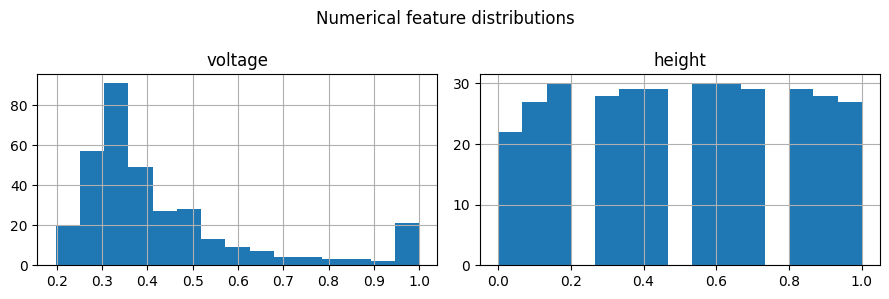


Class counts by split:
            training  test
mine_type                
1                35    36
2                35    35
3                33    33
4                33    33
5                33    32

Distinct feature vectors appearing in both splits: 0

Selected k: 2
Selected weights: uniform
Selected numerical preprocessing: StandardScaler
Mean 5-fold validation accuracy: 47.93%
Standard deviation across folds: 2.20%
These settings have the highest mean validation accuracy among the settings tested. The test half was not used for this selection.


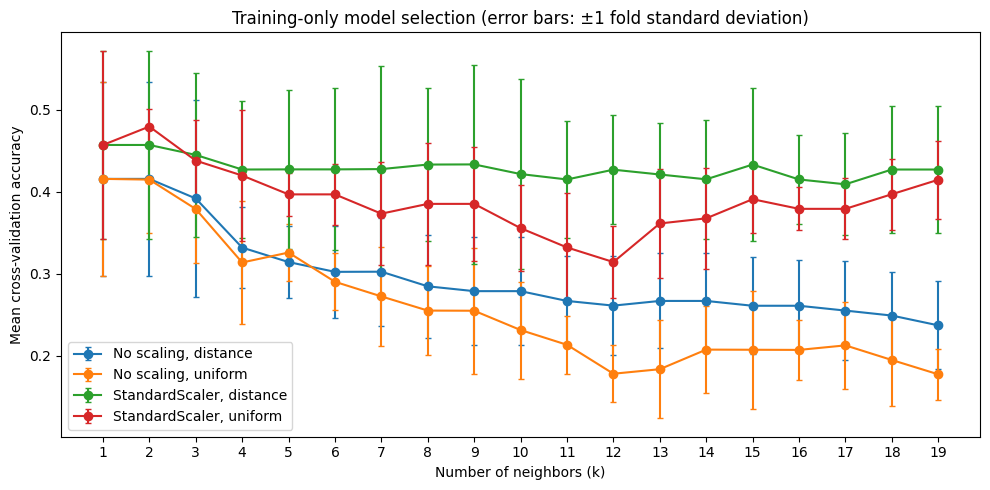


Test accuracy: 47.93%
Majority-class baseline accuracy: 21.30%
Difference from baseline: +26.63 percentage points

Confusion table (rows = actual, columns = predicted):

          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           28            0            6            1            1
Actual 2            0           32            0            3            0
Actual 3           10            1           12            7            3
Actual 4            9            6           10            8            0
Actual 5           10            1           12            8            1


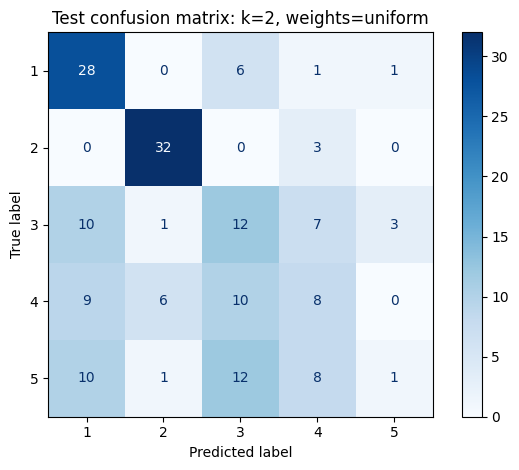


Classification report:

              precision    recall  f1-score   support

           1      0.491     0.778     0.602        36
           2      0.800     0.914     0.853        35
           3      0.300     0.364     0.329        33
           4      0.296     0.242     0.267        33
           5      0.200     0.031     0.054        32

    accuracy                          0.479       169
   macro avg      0.418     0.466     0.421       169
weighted avg      0.425     0.479     0.431       169


Per-class performance:
            actual_count  predicted_count  correct  incorrect_predictions  \
mine_type                                                                  
1                    36               57       28                     29   
2                    35               40       32                      8   
3                    33               40       12                     28   
4                    33               27        8                     19   
5    

In [12]:
# Q2: Phase 2 AI-assisted revision

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# 1. Load and validate the data
features = ["voltage", "height", "soil"]
target = "mine_type"
labels = [1, 2, 3, 4, 5]
required_columns = features + [target]

df = pd.read_csv("land_mines.csv")

missing_columns = set(required_columns) - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df = df[required_columns].copy()

# Convert numeric strings, but reject invalid entries.
for column in required_columns:
    df[column] = pd.to_numeric(df[column], errors="raise")

if not np.isfinite(df.to_numpy(dtype=float)).all():
    raise ValueError("The data contains missing or infinite values.")

if set(df[target].unique()) != set(labels):
    raise ValueError("mine_type must contain all five labels: 1, 2, 3, 4, 5.")

df[target] = df[target].astype(int)

# Soil is treated as a category, rather than assuming distances
# between its numerical codes have a meaningful ordering.
print("Soil is treated as categorical.")
print("Distinct soil codes:", sorted(df["soil"].unique()))


# 2. EDA: summarize the features and target
print(f"\nNumber of observations: {len(df)}")
print("\nData head:\n", df.head())
print("\nNumerical feature summary:\n", df[["voltage", "height"]].describe())

class_counts = df[target].value_counts().sort_index()
print("\nClass distribution:\n", pd.DataFrame({
    "count": class_counts,
    "proportion": class_counts / len(df),
}))

print("\nSoil distribution:\n", df["soil"].value_counts().sort_index())

duplicate_count = df.duplicated().sum()
print(f"\nExact duplicate rows after the first occurrence: {duplicate_count}")

if duplicate_count:
    print(
        "Inspect duplicates before interpreting performance: repeated records "
        "may inflate scores. They are retained because separate measurements "
        "can legitimately have identical values."
    )
    print(df.loc[df.duplicated(keep=False)].head(10))

df[["voltage", "height"]].hist(bins=15, figsize=(9, 3))
plt.suptitle("Numerical feature distributions")
plt.tight_layout()
plt.show()


# 3. Required 50/50 split, preserving class proportions
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y,
)

print("\nClass counts by split:\n", pd.DataFrame({
    "training": y_train.value_counts(),
    "test": y_test.value_counts(),
}).sort_index())

# Identical feature vectors can occur even with different labels.
train_vectors = set(map(tuple, X_train.to_numpy()))
test_vectors = set(map(tuple, X_test.to_numpy()))
overlap_count = len(train_vectors & test_vectors)

print(f"\nDistinct feature vectors appearing in both splits: {overlap_count}")
if overlap_count:
    print(
        "Check whether overlapping observations are independent measurements. "
        "If they come from the same mine or trial, use group-based splitting "
        "and group-based cross-validation instead."
    )


# 4. Select k and other settings using only the training half
# Fit preprocessing separately within each CV fold to avoid leakage.
# Compare unscaled voltage/height against standardized voltage/height.
# Soil is one-hot encoded in both cases.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", ["voltage", "height"]),
        ("soil", OneHotEncoder(handle_unknown="ignore"), ["soil"]),
    ],
    sparse_threshold=0,  # Produce a dense array for k-NN.
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier()),
])

n_splits = min(5, int(y_train.value_counts().min()))
if n_splits < 2:
    raise ValueError("Too few training observations per class for stratified CV.")

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42,
)

# Ensure every k is valid even in the smallest CV training fold.
smallest_fold_size = min(
    len(train_indices)
    for train_indices, _ in cv.split(X_train, y_train)
)
k_values = list(range(1, min(19, smallest_fold_size) + 1))

parameter_grid = {
    "preprocess__numeric": ["passthrough", StandardScaler()],
    "knn__n_neighbors": k_values,
    "knn__weights": ["uniform", "distance"],
}

search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring="accuracy",
    cv=cv,
    refit=True,
    n_jobs=-1,
    error_score="raise",
)

search.fit(X_train, y_train)

# GridSearchCV automatically refits the selected pipeline on all training data.
best_knn = search.best_estimator_
optimal_k = search.best_params_["knn__n_neighbors"]
best_weights = search.best_params_["knn__weights"]
scaling_name = (
    "StandardScaler"
    if isinstance(search.best_params_["preprocess__numeric"], StandardScaler)
    else "No scaling"
)

cv_std = search.cv_results_["std_test_score"][search.best_index_]

print(f"\nSelected k: {optimal_k}")
print(f"Selected weights: {best_weights}")
print(f"Selected numerical preprocessing: {scaling_name}")
print(f"Mean {n_splits}-fold validation accuracy: {search.best_score_:.2%}")
print(f"Standard deviation across folds: {cv_std:.2%}")
print(
    "These settings have the highest mean validation accuracy among the "
    "settings tested. The test half was not used for this selection."
)


# Plot validation accuracy across k for every preprocessing/weight combination.
cv_rows = []
for params, mean_score, std_score in zip(
    search.cv_results_["params"],
    search.cv_results_["mean_test_score"],
    search.cv_results_["std_test_score"],
):
    scaling = (
        "StandardScaler"
        if isinstance(params["preprocess__numeric"], StandardScaler)
        else "No scaling"
    )
    cv_rows.append({
        "k": params["knn__n_neighbors"],
        "setting": f"{scaling}, {params['knn__weights']}",
        "mean_accuracy": mean_score,
        "std_accuracy": std_score,
    })

cv_results = pd.DataFrame(cv_rows)

plt.figure(figsize=(10, 5))
for setting, results in cv_results.groupby("setting"):
    results = results.sort_values("k")
    plt.errorbar(
        results["k"],
        results["mean_accuracy"],
        yerr=results["std_accuracy"],
        marker="o",
        capsize=2,
        label=setting,
    )

plt.xlabel("Number of neighbors (k)")
plt.ylabel("Mean cross-validation accuracy")
plt.title("Training-only model selection (error bars: ±1 fold standard deviation)")
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()


# 5. Final evaluation on the test half
y_pred = best_knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Compare against always predicting the most common training class.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_accuracy = baseline.score(X_test, y_test)

print(f"\nTest accuracy: {accuracy:.2%}")
print(f"Majority-class baseline accuracy: {baseline_accuracy:.2%}")
print(
    f"Difference from baseline: "
    f"{100 * (accuracy - baseline_accuracy):+.2f} percentage points"
)

cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion table (rows = actual, columns = predicted):\n")
print(pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels],
))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
).plot(cmap="Blues")

plt.title(f"Test confusion matrix: k={optimal_k}, weights={best_weights}")
plt.tight_layout()
plt.show()

print("\nClassification report:\n")
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    digits=3,
    zero_division=0,
))


# 6. Interpret class-specific performance using calculated results
true_positives = np.diag(cm)
actual_counts = cm.sum(axis=1)
predicted_counts = cm.sum(axis=0)

# Undefined precision is displayed as NaN if a class is never predicted.
precision = np.divide(
    true_positives,
    predicted_counts,
    out=np.full(len(labels), np.nan),
    where=predicted_counts != 0,
)
recall = true_positives / actual_counts

class_performance = pd.DataFrame({
    "actual_count": actual_counts,
    "predicted_count": predicted_counts,
    "correct": true_positives,
    "incorrect_predictions": predicted_counts - true_positives,
    "missed_actual_cases": actual_counts - true_positives,
    "precision": precision,
    "recall": recall,
}, index=pd.Index(labels, name="mine_type"))

print("\nPer-class performance:\n", class_performance.round(3))

print("\nInterpretation:")
print("Precision: among predictions of a type, how many are correct.")
print("Recall: among actual observations of a type, how many are identified.")

for label, row in class_performance.iterrows():
    precision_text = (
        f"{row['precision']:.1%}"
        if pd.notna(row["precision"])
        else "undefined (this type was never predicted)"
    )
    print(
        f"Type {label}: {int(row['correct'])}/{int(row['actual_count'])} "
        f"actual cases identified (recall {row['recall']:.1%}); "
        f"prediction precision {precision_text}."
    )

print(
    "\nHighest-recall type(s):",
    class_performance.index[
        class_performance["recall"] == class_performance["recall"].max()
    ].tolist(),
)
print(
    "Lowest-recall type(s):",
    class_performance.index[
        class_performance["recall"] == class_performance["recall"].min()
    ].tolist(),
)

errors = cm.copy()
np.fill_diagonal(errors, 0)

if errors.max() > 0:
    print("\nMost frequent misclassification(s):")
    for actual_index, predicted_index in np.argwhere(errors == errors.max()):
        print(
            f"Actual type {labels[actual_index]} predicted as "
            f"type {labels[predicted_index]}: "
            f"{errors[actual_index, predicted_index]} cases."
        )


# 7. Practical interpretation and limitations
print(
    "\nA class can have many correct predictions while also having many "
    "incorrect predictions. The table above shows both, so a large number "
    "of correct predictions alone does not establish reliability."
)
print(
    "For this case study, use the model as supporting information, rather "
    "than as the sole basis for identifying a mine or deciding how to handle "
    "it. Low precision means predicted labels are often wrong; low recall "
    "means many actual cases of that type are missed."
)
print(
    "A prediction of another type does not rule out a poorly detected type. "
    "Any operational use would require independent validation and expert "
    "assessment of which classification errors matter most."
)
print(
    "These changes improve the evaluation procedure but do not guarantee "
    "higher accuracy. Results are based on a small dataset and one split. "
    "Because this dataset was already examined in Phase 1, Phase 2 results "
    "should be treated as exploratory rather than a fresh independent test."
)

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The AI improved how k was chosen, preprocessing, and added more explanatory comments. Overall, it greatly expanded the length of my code, which did make it slightly hard to understand exactly everything it did. The AI took a lot of liberty in modifying my code, likely because the prompt I gave it didn't have constraints on what it could do. Another thing it did that wasn't necessarily a mistake, but something I didn't intend, was that it saw the file in my downloads, then used the file to do its own analysis of the questions so it knew exactly what answers were correct when it wrote the revised code to give to me, as opposed to simply revising my own code. I verified the answer by running all cells, checking that no erroes occured, and checking that the outputs were the same as the outputs from my phase 1 code. I would say my remaining concerns are that there's something in the very long new code block I don't approve of and didn't detect, which I don't think happened, but it's definitely a possibility.